# Quantiles, Percentiles, Five-Number Summary & Box Plot

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [3]:
data = pd.read_excel('retail_sales_dummy_500.xlsx')

In [4]:
data.head()

,Order_ID,Customer_ID,Category,Quantity,Unit_Price,Sales,Discount,Payment_Method
0,1,1081,Office Supplies,5,145,725,0,UPI
1,2,1069,Office Supplies,7,36,252,5,Card
2,3,1077,Office Supplies,4,299,1196,15,UPI
3,4,1000,Furniture,3,1165,3495,5,Card
4,5,1097,Office Supplies,2,214,428,10,UPI


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Order_ID        500 non-null    int64 
 1   Customer_ID     500 non-null    int64 
 2   Category        500 non-null    object
 3   Quantity        500 non-null    int64 
 4   Unit_Price      500 non-null    int64 
 5   Sales           500 non-null    int64 
 6   Discount        500 non-null    int64 
 7   Payment_Method  500 non-null    object
dtypes: int64(6), object(2)
memory usage: 31.4+ KB


In [7]:
data.duplicated().sum()

np.int64(0)

# 

#### 1. Quantiles
Divide data into equal parts.  
Understand how data is distributed.

In [11]:
# First Quartile (25%)
print(data["Sales"].quantile(0.25))

678.75


In [13]:
# Median (50%)
print(data["Sales"].quantile(0.50))

1871.0


In [15]:
# Third Quartile (75%)
print(data["Sales"].quantile(0.75))

5944.5


In [16]:
print(data["Sales"].quantile(0.99))

37649.19999999995


In [18]:
data['Sales'].max()

279480

In [19]:
print(data["Sales"].quantile(1))

279480.0


###### 37,649 and  2,79,480  huge diffrence means may be ouliers contain

# 

In [28]:
print(data["Sales"].quantile(0.2))

491.8


In [26]:
print(data["Sales"].quantile(0.1))

274.80000000000007


In [30]:
print(data["Sales"].quantile(0.01))

69.96000000000001


In [31]:
data['Sales'].min()

40

# 

In [33]:
# Multiple Quantiles
data["Sales"].quantile([0.25, 0.50, 0.75])

0.25     678.75
0.50    1871.00
0.75    5944.50
Name: Sales, dtype: float64

In [34]:
data["Sales"].quantile([0,0.10,0.20,0.30,0.40, 0.50, 0.60,0.70,0.80,0.90,1])

0.0        40.0
0.1       274.8
0.2       491.8
0.3       866.0
0.4      1314.2
0.5      1871.0
0.6      2895.2
0.7      4904.5
0.8      7336.0
0.9     12848.3
1.0    279480.0
Name: Sales, dtype: float64

In [36]:
data["Sales"].quantile([0,0.05,0.10,0.15,0.20,0.25,0.30,0.35,0.40,0.45, 0.50,0.55, 0.60,0.65,0.70,0.75,0.80,0.85,0.90,0.95,1])

0.00        40.00
0.05       173.85
0.10       274.80
0.15       386.55
0.20       491.80
0.25       678.75
0.30       866.00
0.35      1041.25
0.40      1314.20
0.45      1545.50
0.50      1871.00
0.55      2414.50
0.60      2895.20
0.65      3827.00
0.70      4904.50
0.75      5944.50
0.80      7336.00
0.85      9543.20
0.90     12848.30
0.95     18760.90
1.00    279480.00
Name: Sales, dtype: float64

# 

# 

#### 2. Percentiles
- Find the position of a value in a dataset.  
- Used in exams, salaries, customer spending, healthcare, and sports rankings.

In [38]:
print(np.percentile(data["Sales"], 25))

678.75


In [47]:
print(np.percentile(data["Sales"], 50))

1871.0


In [49]:
print(np.percentile(data["Sales"], 90))

12848.300000000007


###### 90th percentile means 90% of the observations are less than or equal to this (12848) value.

# 

In [51]:
# Multiple Percentiles
np.percentile(data["Sales"], [25, 50, 75, 90])

array([  678.75,  1871.  ,  5944.5 , 12848.3 ])

# 

#### 3. Percentage Rank (Percentile Rank)
Determines the percentage of observations below a given value.

In [52]:
data['Sales'].head()

0     725
1     252
2    1196
3    3495
4     428
Name: Sales, dtype: int64

In [55]:
print(stats.percentileofscore(data["Sales"],725))

26.400000000000002


###### Sales value of 725 is higher than 26% of the observations.

In [56]:
print(stats.percentileofscore(data["Sales"],1196))

38.6


In [57]:
data['Sales'].min()

40

In [58]:
print(stats.percentileofscore(data["Sales"],40))

0.2


In [59]:
data['Sales'].max()

279480

In [60]:
print(stats.percentileofscore(data["Sales"],279480))

100.0


In [61]:
print(stats.percentileofscore(data["Sales"],data['Sales'].max()))

100.0


# 

# 

#### 4. Five-Number Summary
The Five-Number Summary quickly describes a dataset and is the foundation of a Box Plot.  
- Minimum
- Q1
- Median
- Q3
- Maximum

In [70]:
data["Sales"].describe()

count       500.000000
mean       5313.278000
std       14393.030789
min          40.000000
25%         678.750000
50%        1871.000000
75%        5944.500000
max      279480.000000
Name: Sales, dtype: float64

In [80]:
five_summary = pd.Series({
    "Minimum": data["Sales"].min(),
    "Q1": data["Sales"].quantile(0.25),
    "Median": data["Sales"].median(),
    "Q3": data["Sales"].quantile(0.75),
    "Maximum": data["Sales"].max()
})

print(five_summary)

Minimum        40.00
Q1            678.75
Median       1871.00
Q3           5944.50
Maximum    279480.00
dtype: float64


In [81]:
data["Sales"].describe()

count       500.000000
mean       5313.278000
std       14393.030789
min          40.000000
25%         678.750000
50%        1871.000000
75%        5944.500000
max      279480.000000
Name: Sales, dtype: float64

 - Mean is greater than median, so the data is right-skewed.
- maximum value is much higher than Q3, so the dataset likely has outliers.
- standard deviation is very high, which means the data is highly spread out.
-  The high standard deviation is mainly because of the outliers.

# 

### Visualization

#### 5. Box Plot
Detects outliers.  
Displays the Five-Number Summary visually.  
Shows skewness and spread.  
One of the most commonly used EDA plots  

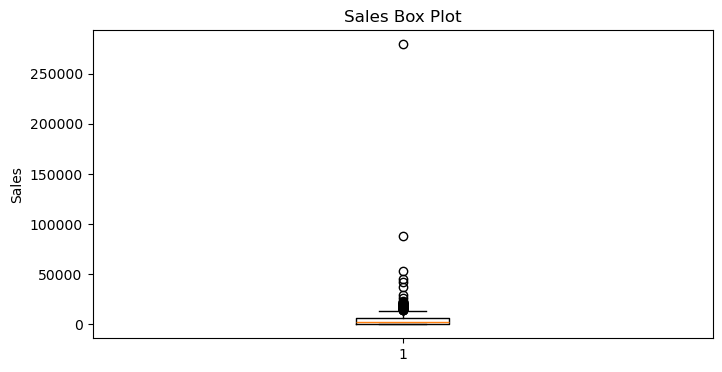

In [90]:
plt.figure(figsize=(8,4))
plt.boxplot(data["Sales"])
plt.title("Sales Box Plot")
plt.ylabel("Sales")
plt.show()

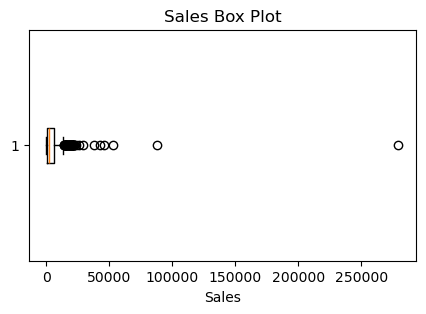

In [102]:
plt.figure(figsize=(5,3))
plt.boxplot(data["Sales"],vert=False)
plt.title("Sales Box Plot")
plt.xlabel("Sales")
plt.show()

# 

#### Outlier Handling

In [105]:
# Calculate IQR
Q1 = data["Sales"].quantile(0.25)
Q3 = data["Sales"].quantile(0.75)

IQR = Q3 - Q1
IQR

np.float64(5265.75)

In [106]:
# another way creating IQR
IQR2 = stats.iqr(data['Sales'])
IQR2

np.float64(5265.75)

In [114]:
# Calculate Lower and Upper Limits
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

Lower Limit: -7219.875
Upper Limit: 13843.125


In [121]:
# Remove Outliers
data_no_outliers = data[(data["Sales"] >= lower_limit) &(data["Sales"] <= upper_limit)]
print(data_no_outliers.shape)

(452, 8)


In [122]:
data.shape

(500, 8)

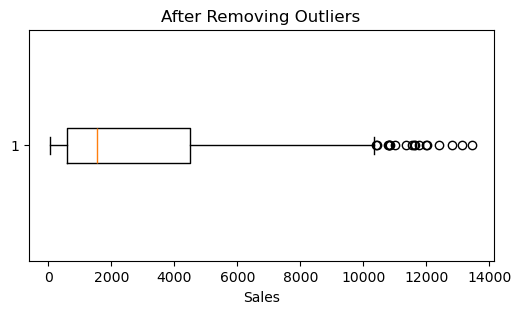

In [125]:
plt.figure(figsize=(6, 3))
plt.boxplot(data_no_outliers["Sales"], vert=False)
plt.title("After Removing Outliers")
plt.xlabel("Sales")
plt.show()

In [127]:
data_no_outliers["Sales"].quantile([0,0.10,0.20,0.30,0.40, 0.50, 0.60,0.70,0.80,0.90,1])

0.0       40.0
0.1      255.5
0.2      452.8
0.3      750.0
0.4     1096.8
0.5     1551.0
0.6     2270.2
0.7     3552.6
0.8     5359.6
0.9     8153.6
1.0    13470.0
Name: Sales, dtype: float64

In [130]:
data_no_outliers["Sales"].quantile([0.75,0.80,0.85,0.89,0.90,0.95,1])

0.75     4488.50
0.80     5359.60
0.85     6488.65
0.89     7643.54
0.90     8153.60
0.95     9978.90
1.00    13470.00
Name: Sales, dtype: float64

In [131]:
data_no_outliers["Sales"].describe()

count      452.000000
mean      2928.758850
std       3152.642518
min         40.000000
25%        585.000000
50%       1551.000000
75%       4488.500000
max      13470.000000
Name: Sales, dtype: float64

# 

In [132]:
# Check if outliers still exist
IQR3 = stats.iqr(data_no_outliers["Sales"])
Q1 = data_no_outliers["Sales"].quantile(0.25)
Q3 = data_no_outliers["Sales"].quantile(0.75)

lower = Q1 - 1.5 * IQR3
upper = Q3 + 1.5 * IQR3

data_no_outliers2= data_no_outliers[(data_no_outliers["Sales"] < lower) |(data_no_outliers["Sales"] > upper)]

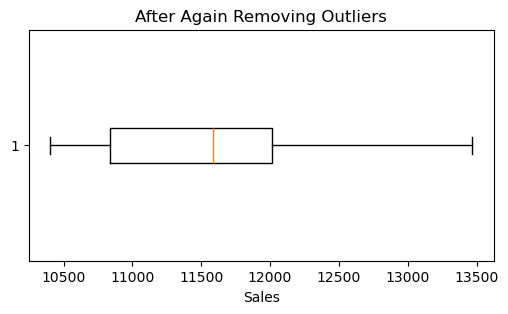

In [135]:
plt.figure(figsize=(6, 3))
plt.boxplot(data_no_outliers2["Sales"], vert=False)
plt.title("After Again Removing Outliers")
plt.xlabel("Sales")
plt.show()

In [153]:
data_no_outliers2['Sales'].describe()

count       18.000000
mean     11607.555556
std        907.223964
min      10400.000000
25%      10840.000000
50%      11583.000000
75%      12011.250000
max      13470.000000
Name: Sales, dtype: float64

##### - repeated outlier removal can remove a large amount of valid data

# 

##### After applying the second outlier removal, most of the data was removed. So, can we increase the lower and upper bounds (increase the IQR multiplier) and see what happens?

In [195]:
Q1 = data["Sales"].quantile(0.25)
Q3 = data["Sales"].quantile(0.75)
IQR = Q3-Q1
lower2 = Q1 - 1 * IQR
upper2 = Q3 + 1 * IQR
data_no_outliers3= data[(data["Sales"] >= lower2) & (data["Sales"] <= upper2)]

In [196]:
data_no_outliers3['Sales'].describe()

count      441.000000
mean      2698.421769
std       2826.898292
min         40.000000
25%        560.000000
50%       1496.000000
75%       4080.000000
max      11008.000000
Name: Sales, dtype: float64

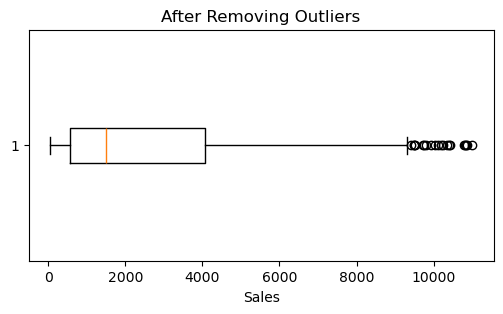

In [197]:
plt.figure(figsize=(6, 3))
plt.boxplot(data_no_outliers3["Sales"], vert=False)
plt.title("After Removing Outliers")
plt.xlabel("Sales")
plt.show()

In [201]:
Q1 = data["Sales"].quantile(0.25)
Q3 = data["Sales"].quantile(0.75)
IQR = Q3-Q1
lower2 = Q1 - 0.5 * IQR
upper2 = Q3 + 0.5 * IQR
data_no_outliers4= data[(data["Sales"] >= lower2) & (data["Sales"] <= upper2)]

In [202]:
data_no_outliers4['Sales'].describe()

count     410.000000
mean     2166.612195
std      2127.169292
min        40.000000
25%       522.000000
50%      1337.000000
75%      3156.000000
max      8508.000000
Name: Sales, dtype: float64

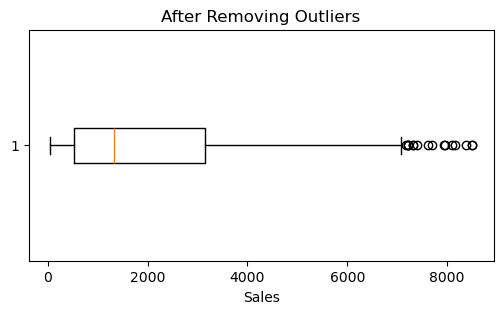

In [203]:
plt.figure(figsize=(6, 3))
plt.boxplot(data_no_outliers4["Sales"], vert=False)
plt.title("After Removing Outliers")
plt.xlabel("Sales")
plt.show()

# 

### Seaborn box plot

In [204]:
import seaborn as sns

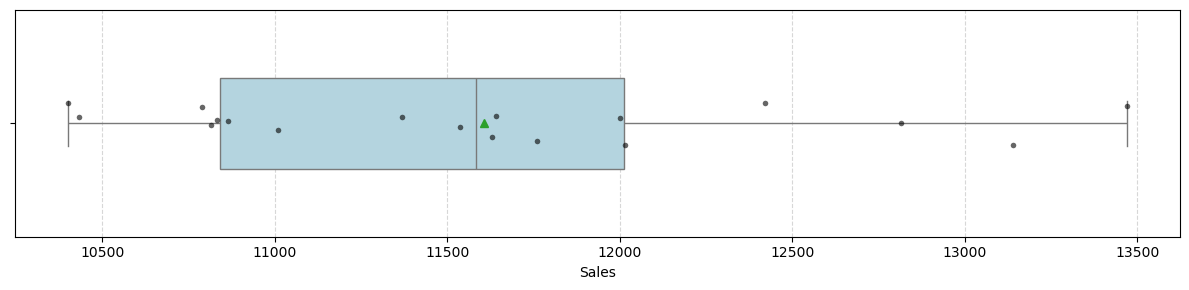

In [205]:
plt.figure(figsize=(12, 3))
sns.boxplot(x=data_no_outliers2["Sales"],color="lightblue",width=0.4,showmeans=True,)
sns.stripplot(x=data_no_outliers2["Sales"],color="black",alpha=0.6,size=4)

plt.xlabel("Sales")
plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# 

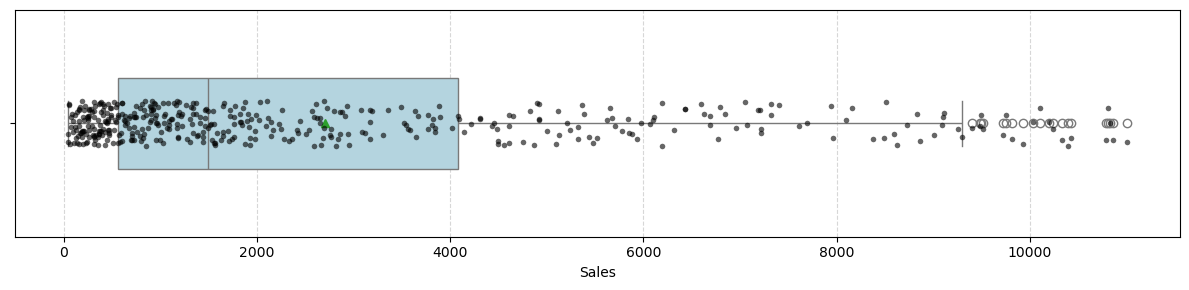

In [207]:
plt.figure(figsize=(12, 3))
sns.boxplot(x=data_no_outliers3["Sales"],color="lightblue",width=0.4,showmeans=True,)
sns.stripplot(x=data_no_outliers3["Sales"],color="black",alpha=0.6,size=4)

plt.xlabel("Sales")
plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

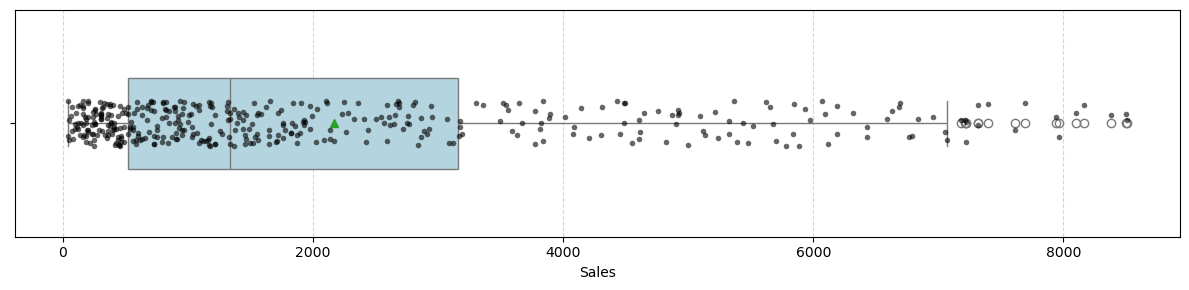

In [208]:
plt.figure(figsize=(12, 3))
sns.boxplot(x=data_no_outliers4["Sales"],color="lightblue",width=0.4,showmeans=True,)
sns.stripplot(x=data_no_outliers4["Sales"],color="black",alpha=0.6,size=4)

plt.xlabel("Sales")
plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# 

###### All compare

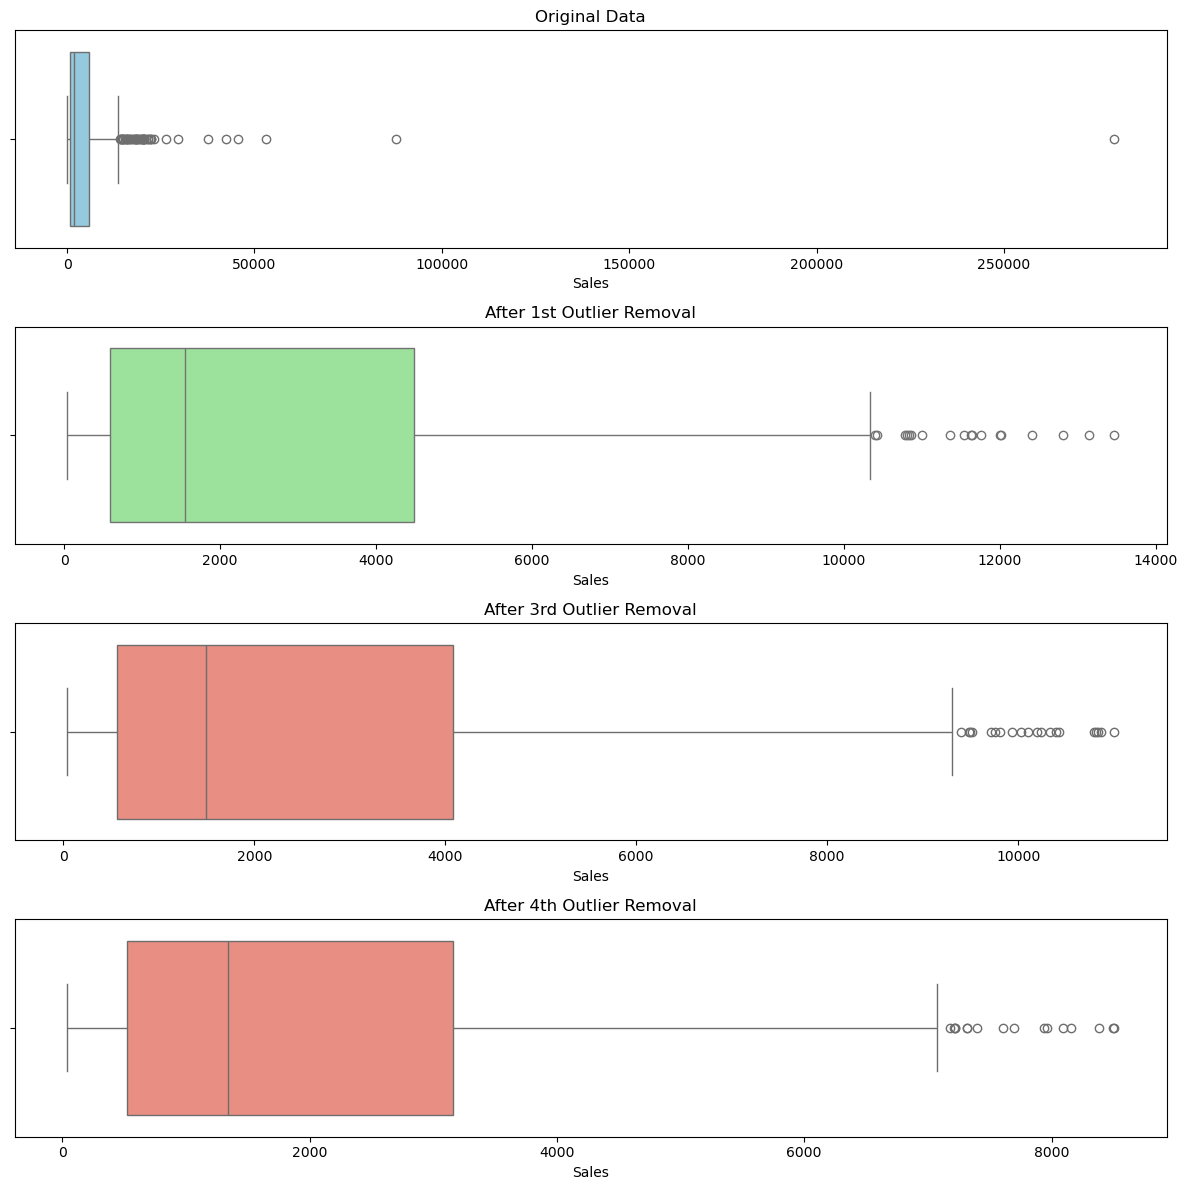

In [210]:
fig, axes = plt.subplots(4, 1, figsize=(12, 12))

# Original Data
sns.boxplot(x=data["Sales"], ax=axes[0], color="skyblue")
axes[0].set_title("Original Data")
axes[0].set_xlabel("Sales")

# After 1st Outlier Removal
sns.boxplot(x=data_no_outliers["Sales"], ax=axes[1], color="lightgreen")
axes[1].set_title("After 1st Outlier Removal")
axes[1].set_xlabel("Sales")

# After 3nd Outlier Removal
sns.boxplot(x=data_no_outliers3["Sales"], ax=axes[2], color="salmon")
axes[2].set_title("After 3rd Outlier Removal")
axes[2].set_xlabel("Sales")

# After 3nd Outlier Removal
sns.boxplot(x=data_no_outliers4["Sales"], ax=axes[3], color="salmon")
axes[3].set_title("After 4th Outlier Removal")
axes[3].set_xlabel("Sales")

plt.tight_layout()
plt.show()

# 

In [211]:
data_no_outliers['Sales'].describe()

count      452.000000
mean      2928.758850
std       3152.642518
min         40.000000
25%        585.000000
50%       1551.000000
75%       4488.500000
max      13470.000000
Name: Sales, dtype: float64

In [212]:
data_no_outliers2['Sales'].describe()

count       18.000000
mean     11607.555556
std        907.223964
min      10400.000000
25%      10840.000000
50%      11583.000000
75%      12011.250000
max      13470.000000
Name: Sales, dtype: float64

In [213]:
data_no_outliers3['Sales'].describe()

count      441.000000
mean      2698.421769
std       2826.898292
min         40.000000
25%        560.000000
50%       1496.000000
75%       4080.000000
max      11008.000000
Name: Sales, dtype: float64

In [214]:
data_no_outliers4['Sales'].describe()

count     410.000000
mean     2166.612195
std      2127.169292
min        40.000000
25%       522.000000
50%      1337.000000
75%      3156.000000
max      8508.000000
Name: Sales, dtype: float64